<a href="https://colab.research.google.com/github/r021n/simple-machine-learing/blob/main/Wine_Quality_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fase 1: Memahami tujuan project dan menyiapkan lingkungan kerja

## Import library yang dibutuhkan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

## Mengatur tampilan dasar notebook

In [2]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 3)

## Mengunduh dataset langsung dari UCI

In [3]:
import urllib.request

red_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
white_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv'

urllib.request.urlretrieve(red_url, 'winequality-red.csv')
urllib.request.urlretrieve(white_url, 'winequality-white.csv')

('winequality-white.csv', <http.client.HTTPMessage at 0x7a43d2b2cf50>)

## Membaca dataset ke pandas DataFrame

In [4]:
df_red = pd.read_csv('winequality-red.csv', sep=';')
df_white = pd.read_csv('winequality-white.csv', sep=';')

## Melihat ukuran data dan baris awal dataset

In [5]:
print('Red wine shape:', df_red.shape)
print('White wine shape:', df_white.shape)

df_red.head()

Red wine shape: (1599, 12)
White wine shape: (4898, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.998,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.997,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.997,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.998,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.998,3.51,0.56,9.4,5


##  Melihat nama-nama kolom dataset

In [6]:
print('Kolom pada dataset red wine')
print(df_red.columns.tolist())

Kolom pada dataset red wine
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']


## Cek informasi umum dataset

In [7]:
df_red.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


##  Melihat statistik deskriptif awal

In [8]:
df_red.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000
mean,8.320,0.528,0.271,2.539,0.087,15.875,46.468,0.997,3.311,0.658,10.423,5.636
std,1.741,0.179,0.195,1.410,0.047,10.460,32.895,0.002,0.154,0.170,1.066,0.808
min,4.600,0.120,0.000,0.900,0.012,1.000,6.000,0.990,2.740,0.330,8.400,3.000
25%,7.100,0.390,0.090,1.900,0.070,7.000,22.000,0.996,3.210,0.550,9.500,5.000
50%,7.900,0.520,0.260,2.200,0.079,14.000,38.000,0.997,3.310,0.620,10.200,6.000
75%,9.200,0.640,0.420,2.600,0.090,21.000,62.000,0.998,3.400,0.730,11.100,6.000
max,15.900,1.580,1.000,15.500,0.611,72.000,289.000,1.004,4.010,2.000,14.900,8.000


## Menentukan dataset kerja utama untuk pembelajaran awal

In [9]:
df = df_red.copy()

print('Dataset kerja yang dipakai:', 'Red Wine')
print('Shape dataset:', df.shape)

df.head()

Dataset kerja yang dipakai: Red Wine
Shape dataset: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.998,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.997,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.997,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.998,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.998,3.51,0.56,9.4,5


## Tujuan project

In [10]:
target_column = 'quality'
feature_columns = [col for col in df.columns if col != target_column]

print('Target:', target_column)
print('Jumlah fitur:', len(feature_columns))
print('Fitur:', feature_columns)

Target: quality
Jumlah fitur: 11
Fitur: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


# Fase 2: Mengenal dan mengeksplorasi dataset

## Mengcek ulang ukuran data, nama kolom, dan beberapa sampel data

In [11]:
print('Shape dataset:', df.shape)
print('\nNama Kolom')
print(df.columns.tolist())

print('\n5 baris pertama')
display(df.head())

print('\n5 baris terakhir')
display(df.tail())

Shape dataset: (1599, 12)

Nama Kolom
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

5 baris pertama


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.998,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.997,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.997,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.998,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.998,3.51,0.56,9.4,5



5 baris terakhir


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.995,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.995,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.996,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.995,3.57,0.71,10.2,5
1598,6.0,0.310,0.47,3.6,0.067,18.0,42.0,0.995,3.39,0.66,11.0,6


## Mengecek tipe data dan missing values

In [12]:
print('Informasi dataset')
df.info()

print('\nJumlah missing values per kolom')
print(df.isnull().sum())

print('\nTotal missing values di seluruh dataset')
print(df.isnull().sum().sum())

Informasi dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB

Jumlah missing values per kolom
fixed acidity           0
volatile acidity        0
citric acid            

## Cek data duplikat

In [13]:
duplicate_count = df.duplicated().sum()

print('Jumlah baris duplikat:', duplicate_count)

if duplicate_count > 0:
  display(df[df.duplicated()].head())

Jumlah baris duplikat: 240


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
4,7.4,0.700,0.00,1.90,0.076,11.0,34.0,0.998,3.51,0.56,9.4,5
11,7.5,0.500,0.36,6.10,0.071,17.0,102.0,0.998,3.35,0.80,10.5,5
27,7.9,0.430,0.21,1.60,0.106,10.0,37.0,0.997,3.17,0.91,9.5,5
40,7.3,0.450,0.36,5.90,0.074,12.0,87.0,0.998,3.33,0.83,10.5,5
65,7.2,0.725,0.05,4.65,0.086,4.0,11.0,0.996,3.41,0.39,10.9,5


## Melihat statistik deskriptif lengkap

In [14]:
desc = df.describe().T
desc['range'] = desc['max'] - desc['min']

display(desc)

,count,mean,std,min,25%,50%,75%,max,range
fixed acidity,1599.0,8.320,1.741,4.600,7.100,7.900,9.200,15.900,11.300
volatile acidity,1599.0,0.528,0.179,0.120,0.390,0.520,0.640,1.580,1.460
citric acid,1599.0,0.271,0.195,0.000,0.090,0.260,0.420,1.000,1.000
residual sugar,1599.0,2.539,1.410,0.900,1.900,2.200,2.600,15.500,14.600
chlorides,1599.0,0.087,0.047,0.012,0.070,0.079,0.090,0.611,0.599
free sulfur dioxide,1599.0,15.875,10.460,1.000,7.000,14.000,21.000,72.000,71.000
total sulfur dioxide,1599.0,46.468,32.895,6.000,22.000,38.000,62.000,289.000,283.000
density,1599.0,0.997,0.002,0.990,0.996,0.997,0.998,1.004,0.014
pH,1599.0,3.311,0.154,2.740,3.210,3.310,3.400,4.010,1.270
sulphates,1599.0,0.658,0.170,0.330,0.550,0.620,0.730,2.000,1.670


## Melihat distribusi target quality

Distribusi nilai quality:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


/tmp/ipykernel_8390/979254196.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='quality', data=df, palette='viridis')


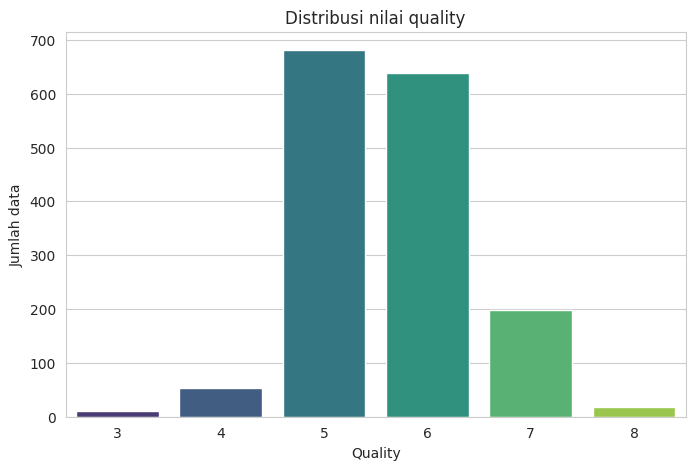

In [15]:
print('Distribusi nilai quality:')
print(df['quality'].value_counts().sort_index())

plt.figure(figsize=(8, 5))
sns.countplot(x='quality', data=df, palette='viridis')
plt.title('Distribusi nilai quality')
plt.xlabel('Quality')
plt.ylabel('Jumlah data')
plt.show()

## Membuat histogram untuk semua fitur numerik

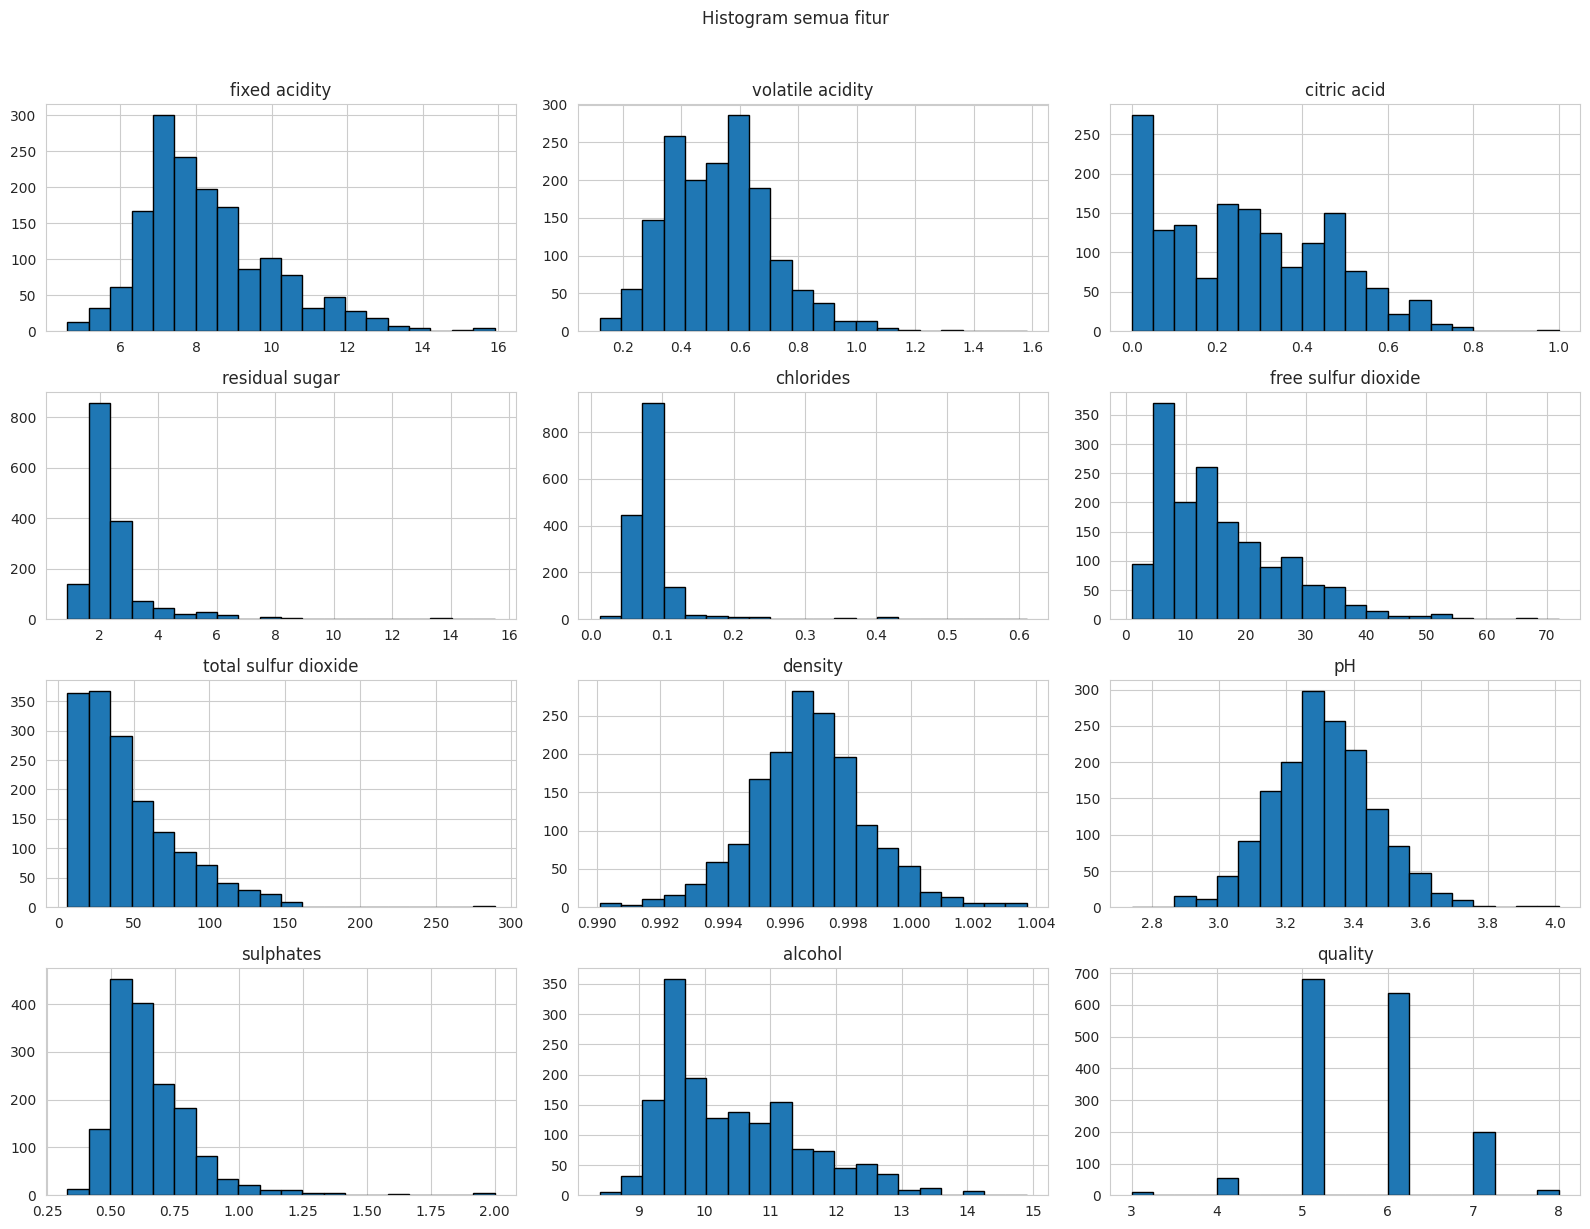

In [16]:
df.hist(bins=20, figsize=(16, 12), edgecolor='black')
plt.suptitle('Histogram semua fitur', y=1.02)
plt.tight_layout()
plt.show()

## Mengecek outlier secara visual dengan boxplot

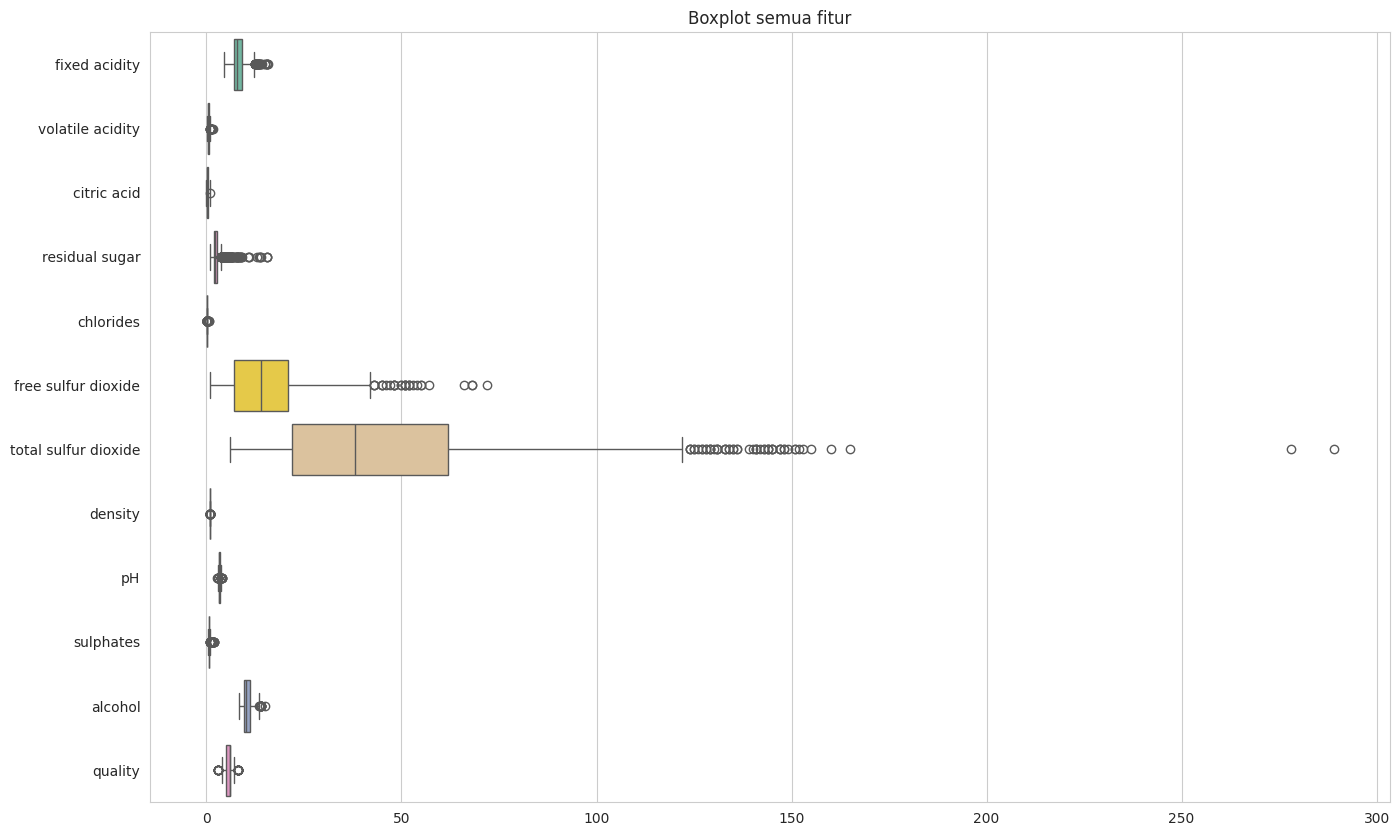

In [17]:
plt.figure(figsize=(16, 10))
sns.boxplot(data=df, orient='h', palette='Set2')
plt.title('Boxplot semua fitur')
plt.show()

## Melihat korelasi antar fitur dan target

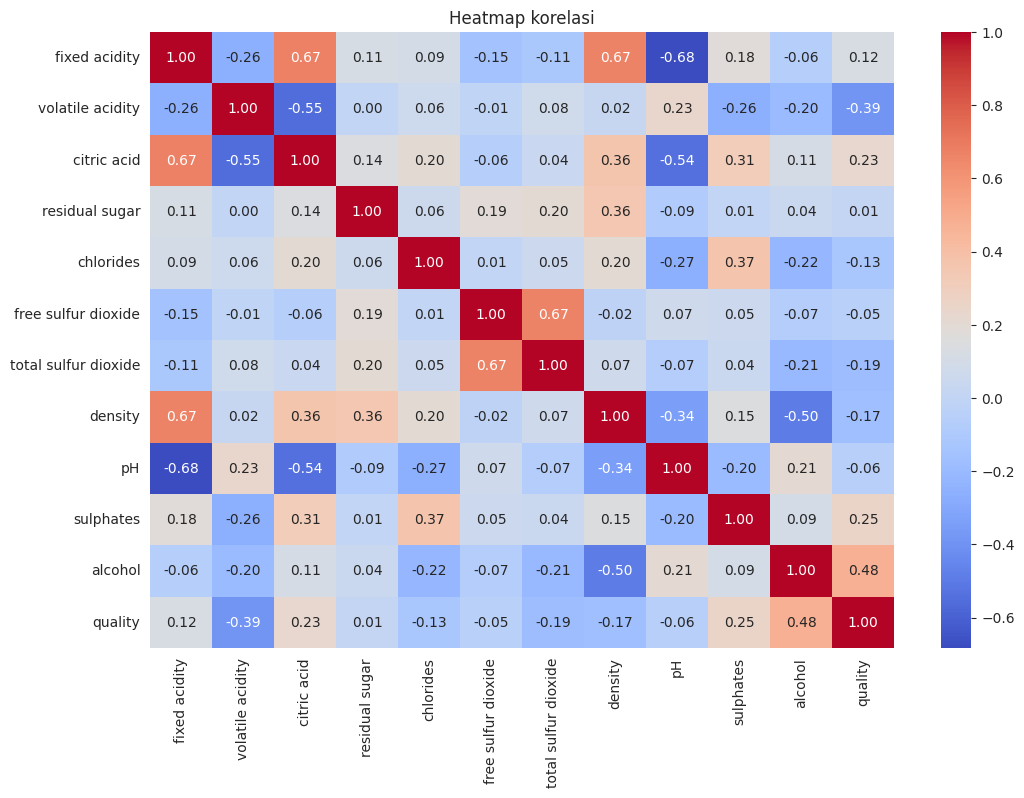

In [18]:
corr_matrix = df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Heatmap korelasi')
plt.show()

## Mengurutkan korelasi fitur terhadap target quality

In [19]:
quality_corr = corr_matrix['quality'].sort_values(ascending=False)

print('Korelasi fitur terhadap quality:')
display(quality_corr)

Korelasi fitur terhadap quality:


,quality
quality,1.000
alcohol,0.476
sulphates,0.251
citric acid,0.226
fixed acidity,0.124
residual sugar,0.014
free sulfur dioxide,-0.051
pH,-0.058
chlorides,-0.129
density,-0.175


## Melihat hubungan beberapa fitur penting dengan target

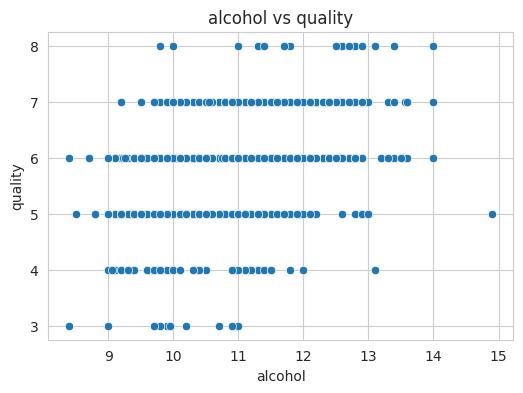

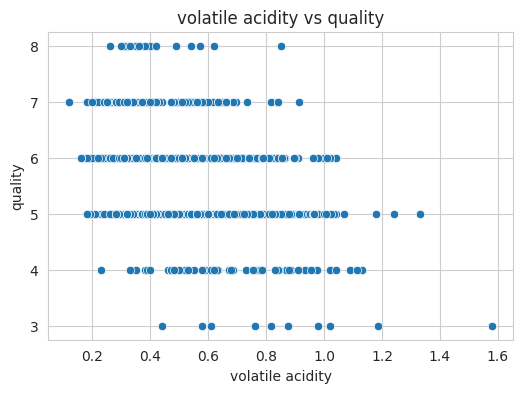

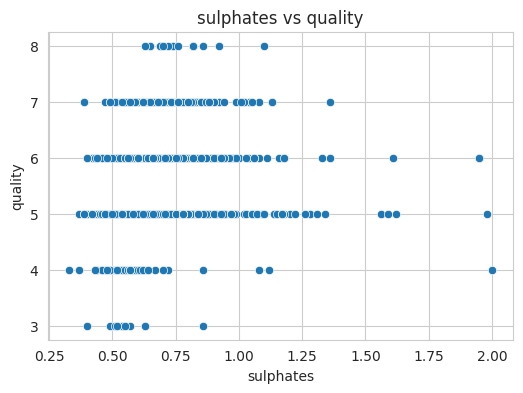

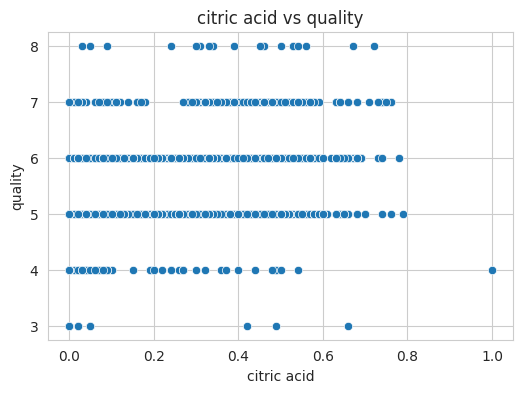

In [20]:
selected_features = ["alcohol", "volatile acidity", "sulphates", "citric acid"]

for col in selected_features:
  plt.figure(figsize=(6, 4))
  sns.scatterplot(x=df[col], y=df["quality"])
  plt.title(f"{col} vs quality")
  plt.xlabel(col)
  plt.ylabel('quality')
  plt.show()

# Fase 3: Membersihkan data dan menyiapkan data untuk modeling

## Membuat salinan data kerja untuk preprocessing

In [21]:
df_model = df.copy()

print('Shape sebelum preprocessing:', df.shape)
display(df.head())

Shape sebelum preprocessing: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.998,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.997,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.997,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.998,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.998,3.51,0.56,9.4,5


## Menghapus baris duplikat jika ada

In [22]:
duplicated_count = df_model.duplicated().sum()
print('Jumlah duplicated sebelum dihapus:', duplicated_count)

df_model = df_model.drop_duplicates()

print('Shape setelah hapus duplikat:', df_model.shape)
print('Jumlah duplicated setelah penghapusan:', df_model.duplicated().sum())

Jumlah duplicated sebelum dihapus: 240
Shape setelah hapus duplikat: (1359, 12)
Jumlah duplicated setelah penghapusan: 0


## Memastikan tidak ada missing values

In [23]:
missing_per_column = df_model.isnull().sum()

print('Missing valus per kolom:')
print(missing_per_column)

print('\nTotal missing values:', missing_per_column.sum())

Missing valus per kolom:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Total missing values: 0


## Menetapkan fitur input dan target

In [24]:
target_column = 'quality'
feature_columns = [col for col in df_model.columns if col != target_column]

X = df_model[feature_columns]
y = df_model[target_column]

print('Jumlah fitur:', X.shape[1])
print('Shape x:', X.shape)
print('Shape y:', y.shape)

Jumlah fitur: 11
Shape x: (1359, 11)
Shape y: (1359,)


## Melihat contoh fitur dan target

In [25]:
print('Contoh data fitur')
display(X.head())

print('\nContoh target')
display(y.head())

Contoh data fitur


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.998,3.51,0.56,9.4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.997,3.20,0.68,9.8
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.997,3.26,0.65,9.8
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.998,3.16,0.58,9.8
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.998,3.51,0.56,9.4



Contoh target


,quality
0,5
1,5
2,5
3,6
5,5


## Membagi data menjadi train dan test set

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print('Shape X_train:', X_train.shape)
print('Shape X_test:', X_test.shape)
print('Shape y_train:', y_train.shape)
print('Shape y_test:', y_test.shape)

Shape X_train: (1087, 11)
Shape X_test: (272, 11)
Shape y_train: (1087,)
Shape y_test: (272,)


## Menerapkan feature scaling dengan StandardScaler

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Shape X_train_scaled:', X_train_scaled.shape)
print('Shape X_test_scaled:', X_test_scaled.shape)

Shape X_train_scaled: (1087, 11)
Shape X_test_scaled: (272, 11)


## Mengubah hasil scaling ke DataFrame agar lebih mudah dibaca

In [28]:
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print(X_train_scaled_df.head())

      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
1016          0.352            -0.828        0.649          -0.238     -0.412   
1519         -0.982             0.966       -0.990           0.055      0.313   
452          -0.866             0.181       -1.246          -0.605     -0.107   
847          -0.518             0.854       -0.580          -0.531     -0.221   
58           -0.286             0.349       -0.478          -0.165     -0.259   

      free sulfur dioxide  total sulfur dioxide  density     pH  sulphates  \
1016               -0.362                -0.566   -0.987 -0.260      0.520   
1519               -0.168                -0.596   -0.026  0.857     -0.458   
452                 0.219                -0.356    0.055  0.857     -0.171   
847                -0.362                -0.236    0.538  1.252      0.232   
58                  0.122                 0.215    0.431  0.792     -0.401   

      alcohol  
1016    1.984  
1519   -0.21

## Mengecek ringkasan hasil scaling

In [29]:
scaling_summary = X_train_scaled_df.describe().T[['mean', 'std', 'min', 'max']]
display(scaling_summary.head(10))

,mean,std,min,max
fixed acidity,3.579e-16,1.0,-2.141,4.409
volatile acidity,-1.144e-16,1.0,-2.062,5.900
citric acid,-4.576e-17,1.0,-1.399,3.721
residual sugar,-2.615e-17,1.0,-1.191,9.505
chlorides,8.334e-17,1.0,-1.479,9.940
free sulfur dioxide,-1.471e-17,1.0,-1.427,5.446
total sulfur dioxide,1.307e-17,1.0,-1.227,7.275
density,-9.975e-15,1.0,-3.559,3.754
pH,-3.020e-15,1.0,-3.743,3.880
sulphates,-4.118e-16,1.0,-1.897,7.714


## Menyimpan data final yang siap untuk modeling

In [30]:
X_train_final = X_train_scaled
X_test_final = X_test_scaled
y_train_final = y_train.copy()
y_test_final = y_test.copy()

print("Data siap untuk modeling.")
print("X_train_final:", X_train_final.shape)
print("X_test_final:", X_test_final.shape)
print("y_train_final:", y_train_final.shape)
print("y_test_final:", y_test_final.shape)

Data siap untuk modeling.
X_train_final: (1087, 11)
X_test_final: (272, 11)
y_train_final: (1087,)
y_test_final: (272,)


# Fase 4: Membangun baseline model dan memahami evaluasi

## Mengimport baseline model dan metrik evaluasi

In [31]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Membuat dan melatih baseline model

In [32]:
baseline_model = LinearRegression()
baseline_model.fit(X_train_final, y_train_final)
print("Baseline model berhasil dilatih")

Baseline model berhasil dilatih


## Melakukan prediksi pada data train dan data test

In [33]:
y_train_pred = baseline_model.predict(X_train_final)
y_test_pred = baseline_model.predict(X_test_final)

print("Contoh prediksi train:", y_train_pred[:5])
print("Contoh prediksi test:", y_test_pred[:5])

Contoh prediksi train: [6.58586514 5.31540777 5.48079422 5.30201782 5.33699816]
Contoh prediksi test: [5.24560141 5.80993501 6.36840525 5.15873325 5.19928608]


## Menghitung metrik evaluasi untuk data train dan data test

In [34]:
train_mae = mean_absolute_error(y_train_final, y_train_pred)
train_mse = mean_squared_error(y_train_final, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train_final, y_train_pred)

test_mae = mean_absolute_error(y_test_final, y_test_pred)
test_mse = mean_squared_error(y_test_final, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test_final, y_test_pred)

## Menampilkan metrik hasil evaluasi baseline model

In [35]:
print("Hasil evaluasi baseline model")
print("\nTrain Metrics")
print("MAE  :", round(train_mae, 4))
print("MSE  :", round(train_mse, 4))
print("RMSE :", round(train_rmse, 4))
print("R2   :", round(train_r2, 4))

print("\nTest Metrics")
print("MAE  :", round(test_mae, 4))
print("MSE  :", round(test_mse, 4))
print("RMSE :", round(test_rmse, 4))
print("R2   :", round(test_r2, 4))

Hasil evaluasi baseline model

Train Metrics
MAE  : 0.5107
MSE  : 0.4337
RMSE : 0.6585
R2   : 0.352

Test Metrics
MAE  : 0.5041
MSE  : 0.431
RMSE : 0.6565
R2   : 0.3915


## Membandingkan nilai aktual dengan nilai prediksi

In [36]:
comparison_df = pd.DataFrame({
    "actual": y_test_final.values,
    "predicted": y_test_pred
})

comparison_df["error"] = comparison_df["actual"] - comparison_df["predicted"]
display(comparison_df.head(10))

,actual,predicted,error
0,5,5.246,-0.246
1,6,5.810,0.190
2,7,6.368,0.632
3,5,5.159,-0.159
4,4,5.199,-1.199
5,7,6.776,0.224
6,5,5.707,-0.707
7,5,4.845,0.155
8,6,5.800,0.200
9,5,5.739,-0.739


## Visualisasi aktual vs prediksi

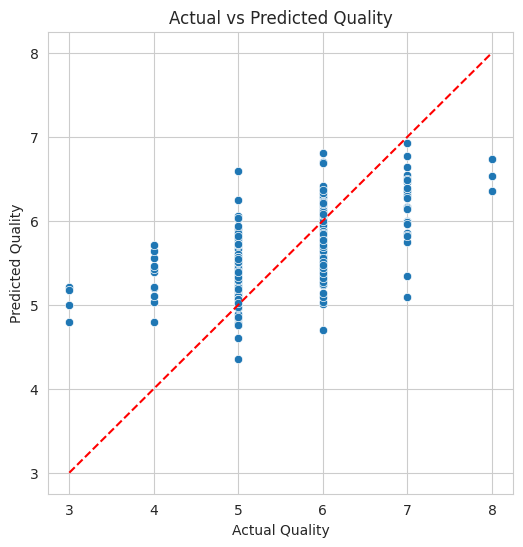

In [37]:
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test_final, y=y_test_pred)
plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")
plt.title("Actual vs Predicted Quality")

min_val = min(y_test_final.min(), y_test_pred.min())
max_val = max(y_test_final.max(), y_test_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--")

plt.show()

## Memvisualisasikan distribusi error

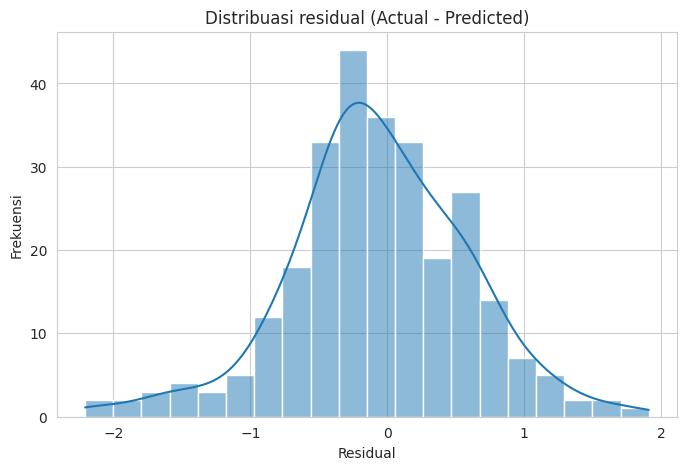

In [38]:
residuals = y_test_final - y_test_pred

plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=20, kde=True)
plt.title("Distribuasi residual (Actual - Predicted)")
plt.xlabel("Residual")
plt.ylabel("Frekuensi")
plt.show()

## Melihat koefisien model linear

In [39]:
coefficients_df = pd.DataFrame({
    "feature": feature_columns,
    "coefficient": baseline_model.coef_
}).sort_values(by="coefficient", ascending=False)

display(coefficients_df)

,feature,coefficient
10,alcohol,0.334
9,sulphates,0.148
5,free sulfur dioxide,0.049
7,density,0.042
3,residual sugar,-0.005
2,citric acid,-0.019
0,fixed acidity,-0.050
4,chlorides,-0.116
8,pH,-0.122
6,total sulfur dioxide,-0.124


## Ringkasan hasil baseline

In [40]:
baseline_results = pd.DataFrame({
    "dataset": ["train", "test"],
    "MAE": [train_mae, test_mae],
    "MSE": [train_mse, test_mse],
    "RMSE": [train_rmse, test_rmse],
    "R2": [train_r2, test_r2]
})

display(baseline_results)

,dataset,MAE,MSE,RMSE,R2
0,train,0.511,0.434,0.659,0.352
1,test,0.504,0.431,0.657,0.392


# Fase 5: Meningkatkan performa dengan ensemble methods

## Mengimport model ensemble dan tools evaluasi

In [41]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Membuat fungsi untuk evaluasi model

In [42]:
def evaluate_regression(model, X_train, y_train, X_test, y_test, model_name="Model"):
  y_train_pred = model.predict(X_train)
  y_test_pred = model.predict(X_test)

  train_mae = mean_absolute_error(y_train, y_train_pred)
  train_mse = mean_squared_error(y_train, y_train_pred)
  train_rmse = np.sqrt(train_mse)
  train_r2 = r2_score(y_train, y_train_pred)

  test_mae = mean_absolute_error(y_test, y_test_pred)
  test_mse = mean_squared_error(y_test, y_test_pred)
  test_rmse = np.sqrt(test_mse)
  test_r2 = r2_score(y_test, y_test_pred)

  results = pd.DataFrame({
      "model": [model_name],
      "train_MAE": [train_mae],
      "train_MSE": [train_mse],
      "train_RMSE": [train_rmse],
      "train_R2": [train_r2],
      "test_MAE": [test_mae],
      "test_MSE": [test_mse],
      "test_RMSE": [test_rmse],
      "test_R2": [test_r2],
  })

  return results, y_test_pred

## Melatih random forest regressor versi awal

In [43]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_final, y_train_final)
print("Random forest model berhasil dilatih")

Random forest model berhasil dilatih


## Evaluasi random forest versi awal

In [44]:
rf_results, rf_y_test_pred = evaluate_regression(
    rf_model,
    X_train_final, y_train_final,
    X_test_final, y_test_final,
    model_name="Random Forest"
)

display(rf_results)

,model,train_MAE,train_MSE,train_RMSE,train_R2,test_MAE,test_MSE,test_RMSE,test_R2
0,Random Forest,0.185,0.058,0.242,0.913,0.468,0.384,0.62,0.458


## Melatih gradient boosting versi awal

In [45]:
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

gb_model.fit(X_train_final, y_train_final)
print("Gradient boosting model berhasil dilatih")

Gradient boosting model berhasil dilatih


## Evaluasi gradient boosting level awal

In [46]:
gb_results, gb_y_test_pred = evaluate_regression(
    gb_model,
    X_train_final, y_train_final,
    X_test_final, y_test_final,
    model_name="Gradient Boosting"
  )

display(gb_results)

,model,train_MAE,train_MSE,train_RMSE,train_R2,test_MAE,test_MSE,test_RMSE,test_R2
0,Gradient Boosting,0.393,0.244,0.494,0.635,0.479,0.384,0.619,0.459


## Membandingkan model baseline dengan model ensemble

In [47]:
baseline_results_comparison = baseline_results.copy()
baseline_results_comparison["model"] = "LinearRegresion"

baseline_results_comparison = baseline_results_comparison[baseline_results_comparison["dataset"] == "test"].copy()
baseline_results_comparison = baseline_results_comparison.rename(columns={
    "MAE": "test_MAE",
    "MSE": "test_MSE",
    "RMSE": "test_RMSE",
    "R2": "test_R2"
})

comparison_df = pd.concat([
    baseline_results_comparison[["model", "test_MAE", "test_MSE", "test_RMSE", "test_R2"]],
    rf_results[["model", "test_MAE", "test_MSE", "test_RMSE", "test_R2"]],
    gb_results[["model", "test_MAE", "test_MSE", "test_RMSE", "test_R2"]]
], ignore_index=True)

display(comparison_df.sort_values(by="test_RMSE"))

,model,test_MAE,test_MSE,test_RMSE,test_R2
2,Gradient Boosting,0.479,0.384,0.619,0.459
1,Random Forest,0.468,0.384,0.620,0.458
0,LinearRegresion,0.504,0.431,0.657,0.392


## Tuning sederhana pada random forest

In [48]:
rf_tuned = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf_tuned.fit(X_train_final, y_train_final)

rf_tuned_results, rf_tuned_y_test_pred = evaluate_regression(
    rf_tuned,
    X_train_final, y_train_final,
    X_test_final, y_test_final,
    model_name="Random Forest Tuned"
)

display(rf_tuned_results)

,model,train_MAE,train_MSE,train_RMSE,train_R2,test_MAE,test_MSE,test_RMSE,test_R2
0,Random Forest Tuned,0.28,0.132,0.363,0.803,0.465,0.379,0.615,0.466


## Tuning sederhana pada gradient boosting

In [49]:
gb_tuned = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_tuned.fit(X_train_final, y_train_final)

gb_tuned_results, gb_tuned_y_test_pred = evaluate_regression(
    gb_tuned,
    X_train_final, y_train_final,
    X_test_final, y_test_final,
    model_name="Gradient Boosting Tuned"
)

display(gb_tuned_results)

,model,train_MAE,train_MSE,train_RMSE,train_R2,test_MAE,test_MSE,test_RMSE,test_R2
0,Gradient Boosting Tuned,0.355,0.203,0.45,0.697,0.488,0.396,0.629,0.441


## Menggabungkan semua hasil model untuk memilih model terbaik

In [50]:
all_results = pd.concat([
    baseline_results_comparison[["model", "test_MAE", "test_MSE", "test_RMSE", "test_R2"]],
    rf_results[["model", "test_MAE", "test_MSE", "test_RMSE", "test_R2"]],
    gb_results[["model", "test_MAE", "test_MSE", "test_RMSE", "test_R2"]],
    rf_tuned_results[["model", "test_MAE", "test_MSE", "test_RMSE", "test_R2"]],
    gb_tuned_results[["model", "test_MAE", "test_MSE", "test_RMSE", "test_R2"]]
], ignore_index=True)

all_results_sorted = all_results.sort_values(by="test_RMSE").reset_index(drop=True)
display(all_results_sorted)

,model,test_MAE,test_MSE,test_RMSE,test_R2
0,Random Forest Tuned,0.465,0.379,0.615,0.466
1,Gradient Boosting,0.479,0.384,0.619,0.459
2,Random Forest,0.468,0.384,0.620,0.458
3,Gradient Boosting Tuned,0.488,0.396,0.629,0.441
4,LinearRegresion,0.504,0.431,0.657,0.392
